In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.tri as mtri
import uxarray as ux

import parcels

/var/folders/1n/500ln6w97859_nqq86vwpl000000gr/T/ipykernel_79341/3149933764.py:8: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


In [2]:
file = "maps2d_dcsm7_harmonie_202311140000.nc"
ds = xr.open_dataset(file)
# ds.load()
ds

<xarray.Dataset> Size: 2GB
Dimensions:             (nMesh_node: 1554681, nMesh_edge: 3088294,
                         nMesh_face: 1532644, nMaxMesh_face_bounds: 4,
                         nMaxMesh_edge_nodes: 2, nMaxMesh_face_nodes: 4,
                         time: 52, analysis_time: 1)
Coordinates:
    Mesh_face_x         (nMesh_face) float64 12MB ...
    Mesh_face_y         (nMesh_face) float64 12MB ...
  * time                (time) datetime64[ns] 416B 2023-11-13T21:00:00 ... 20...
  * analysis_time       (analysis_time) datetime64[ns] 8B 2023-11-14
Dimensions without coordinates: nMesh_node, nMesh_edge, nMesh_face,
                                nMaxMesh_face_bounds, nMaxMesh_edge_nodes,
                                nMaxMesh_face_nodes
Data variables: (12/14)
    Mesh                int32 4B ...
    Mesh_node_x         (nMesh_node) float64 12MB ...
    Mesh_node_y         (nMesh_node) float64 12MB ...
    Mesh_edge_x         (nMesh_edge) float64 25MB ...
    Mesh_edge_y         (nMesh_edge) float64 25MB ...
    Mesh_face_bounds_x  (nMesh_face, nMaxMesh_face_bounds) float64 49MB ...
    ...                  ...
    Mesh_face_nodes     (nMesh_face, nMaxMesh_face_nodes) float64 49MB ...
    crs                 int32 4B ...
    sep                 (time, nMesh_face) float32 319MB ...
    velu                (time, nMesh_face) float32 319MB ...
    velv                (time, nMesh_face) float32 319MB ...
    veluv_abs           (time, nMesh_face) float32 319MB ...
Attributes: (12/25)
    Conventions:                  CF-1.6,UGRID-0.9
    title:                        Water level and flow velocity simulated his...
    institution:                  Rijkswaterstaat-HMC
    source:                       dflowfm2d_noordzee_100m-j22_6-v1a_harmonie
    history:                      2023-11-14 03:24:39 GMT: exported from Delf...
    references:                   https://www.helpdeskwater.nl/onderwerpen/ap...
    ...                           ...
    assimilation_method:          not applicable
    meteo_forcing_source:         knmi_harmonie
    meteo_analysis_time:          2023-11-14 00:00:00 GMT
    fews_implementation_version:  2021.02
    fews_patch_number:            123320
    fews_build_number:            110372

In [3]:
last_col = ds["Mesh_face_nodes"].isel(nMaxMesh_face_nodes=3)
triangles = np.sum(np.isnan(last_col.values))
print(f"Number of triangles: {triangles}")
rectangles = np.sum(~ np.isnan(last_col.values))
print(f"Number of rectangles: {rectangles}")
print(f"Total nodes before triangulation: {triangles + rectangles}")
print(f"Total nodes after triangulation: {triangles+2*rectangles}")


Number of triangles: 39942
Number of rectangles: 1492702
Total nodes before triangulation: 1532644
Total nodes after triangulation: 3025346


Original faces: 1532644, triangular faces: 3025346


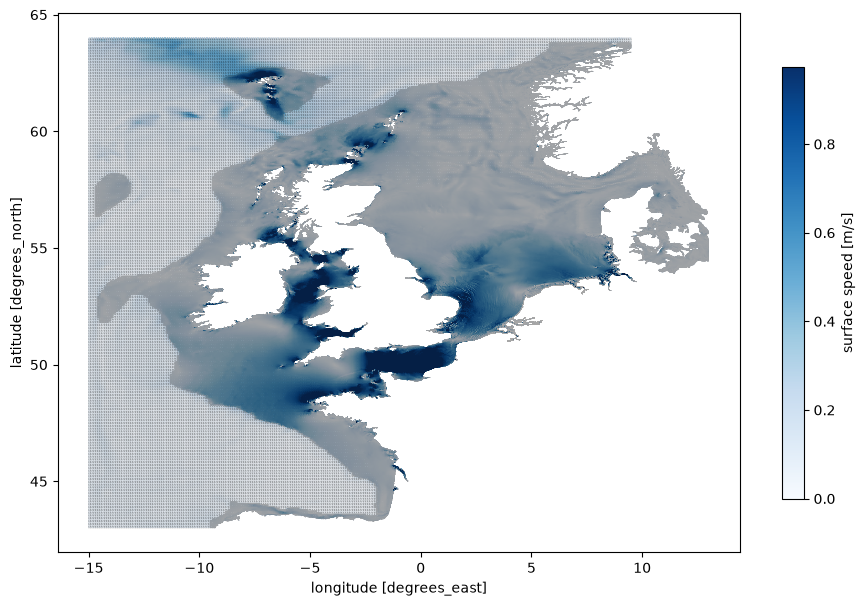

In [4]:
node_x = ds["Mesh_node_x"].values
node_y = ds["Mesh_node_y"].values
raw_face_nodes = ds["Mesh_face_nodes"].values

# Keep original mesh connectivity (0-based, padded with -1) for uxgrid/parcels.
orig_face_nodes = np.where(np.isfinite(raw_face_nodes), raw_face_nodes - 1, -1).astype("int64")

# Use integer-safe connectivity for triangulation logic (1-based with 0 as invalid).
raw_face_nodes_i = np.where(np.isfinite(raw_face_nodes), raw_face_nodes, 0).astype("int64")

tri_list = []
tri_parent_face = []

for i, face in enumerate(raw_face_nodes_i):
    # UGRID connectivity is typically 1-based with 0/-1 as fill values.
    valid = face[face > 0] - 1
    n_valid = valid.size

    if n_valid < 3:
        continue
    if n_valid == 3:
        tri_list.append(valid)
        tri_parent_face.append(i)
        continue

    if n_valid == 4:
        a, b, c, d = valid
        diag_ac = (node_x[a] - node_x[c]) ** 2 + (node_y[a] - node_y[c]) ** 2
        diag_bd = (node_x[b] - node_x[d]) ** 2 + (node_y[b] - node_y[d]) ** 2

        if diag_ac <= diag_bd:
            tri_list.extend([[a, b, c], [a, c, d]])
        else:
            tri_list.extend([[a, b, d], [b, c, d]])
        tri_parent_face.extend([i, i])
        continue

    # Fallback for polygons with >4 nodes: simple fan triangulation.
    for j in range(1, n_valid - 1):
        tri_list.append([valid[0], valid[j], valid[j + 1]])
        tri_parent_face.append(i)

tri_faces = np.asarray(tri_list, dtype="int64")
tri_parent_face = np.asarray(tri_parent_face, dtype="int64")

triang = mtri.Triangulation(node_x, node_y, triangles=tri_faces)
tri_speed = ds["veluv_abs"].isel(time=0).isel(nMesh_face=xr.DataArray(tri_parent_face, dims="n_face")).values

fig, ax = plt.subplots(figsize=(11, 7))
tpc = ax.tripcolor(
    triang,
    facecolors=tri_speed,
    shading="flat",
    cmap="Blues",
    vmax=np.nanpercentile(tri_speed, 98),
)
ax.triplot(triang, color="k", lw=0.2, alpha=0.35)
ax.set_xlabel("longitude [degrees_east]")
ax.set_ylabel("latitude [degrees_north]")
fig.colorbar(tpc, ax=ax, label="surface speed [m/s]", shrink=0.8)
print(f"Original faces: {raw_face_nodes_i.shape[0]}, triangular faces: {tri_faces.shape[0]}")
plt.show()

In [5]:
# Set vertical coordinates for the dataset
zf = [0, 1]
zc = [0.5]

# Parcels requires a purely triangular UGRID mesh.
uxgrid = ux.Grid.from_topology(
    node_lon=ds["Mesh_node_x"],
    node_lat=ds["Mesh_node_y"],
    face_node_connectivity=tri_faces,
    fill_value=-1,
)

# Fast remap from original faces -> triangular faces using NumPy indexing.
tri_parent_idx = tri_parent_face.astype(np.intp, copy=False)

def to_face_3d(var_name, target_name):
    src = ds[var_name].transpose("time", "nMesh_face").astype("float32")
    tri_vals = np.take(src.values, tri_parent_idx, axis=1)
    return xr.DataArray(
        tri_vals[:, np.newaxis, :],
        dims=("time", "zc", "n_face"),
        coords={"time": ds["time"], "zc": zc},
        name=target_name,
        attrs=src.attrs,
    )

velocity_data = {
    "U": to_face_3d("velu", "U"),
    "V": to_face_3d("velv", "V"),
}

uxds = ux.UxDataset(
    xr.Dataset(
        velocity_data,
        coords={"zf": ("zf", zf), "zc": ("zc", zc), "time": ds["time"]},
    ),
    uxgrid=uxgrid,
)
uxds

<xarray.UxDataset> Size: 1GB
Dimensions:  (time: 52, zc: 1, n_face: 3025346, zf: 2)
Coordinates:
  * time     (time) datetime64[ns] 416B 2023-11-13T21:00:00 ... 2023-11-16
  * zc       (zc) float64 8B 0.5
  * zf       (zf) int64 16B 0 1
Dimensions without coordinates: n_face
Data variables:
    U        (time, zc, n_face) float32 629MB 0.0 0.0 0.0 ... 0.099 0.104 0.104
    V        (time, zc, n_face) float32 629MB 0.0 0.0 0.0 ... 0.008 0.005 0.005

In [6]:
fieldset = parcels.FieldSet.from_ugrid_conventions(uxds, mesh="spherical")

for name, field in fieldset.fields.items():
    print(
        f"{name:>4s} -> {type(field).__name__:<11s} interp={field.interp_method}"
    )
print("time interval:", fieldset.time_interval)

   U -> Field       interp=<parcels.interpolators._uxinterpolators.UxConstantFaceConstantZC object at 0x36004e7b0>
   V -> Field       interp=<parcels.interpolators._uxinterpolators.UxConstantFaceConstantZC object at 0x360051bd0>
  UV -> VectorField interp=<parcels.interpolators._uxinterpolators.Ux_Velocity object at 0x360051e50>
time interval: TimeInterval(left=np.datetime64('2023-11-13T21:00:00.000000000'), right=np.datetime64('2023-11-16T00:00:00.000000000'))


In [7]:
N = 900
# X, Y = np.meshgrid(np.linspace(4.2, 4.4, int(np.sqrt(N))), np.linspace(52.2, 52.4, int(np.sqrt(N))))
X, Y = np.meshgrid(np.linspace(4.5, 6, int(np.sqrt(N))), np.linspace(52.8, 53.6, int(np.sqrt(N))))

pset = parcels.ParticleSet(fieldset, lon=X, lat=Y)
output_file = parcels.ParticleFile(
    "output-matroos.parquet",
    outputdt=np.timedelta64(30, "m"),
    mode="w",
)

def DeleteAnyError(particles, fieldset):
    any_error = particles.state >= 50  # This captures all Errors
    particles[any_error].state = parcels.StatusCode.Delete

pset.execute(
    [parcels.kernels.AdvectionRK2, DeleteAnyError],
    runtime=np.timedelta64(2, "D"),
    dt=np.timedelta64(10, "m"),
    output_file=output_file,
)

INFO: Output files are stored in output-matroos.parquet
Integration time: 2023-11-15T20:30:00 100%|██████████| [17:27<00:00, 164.90it/s]


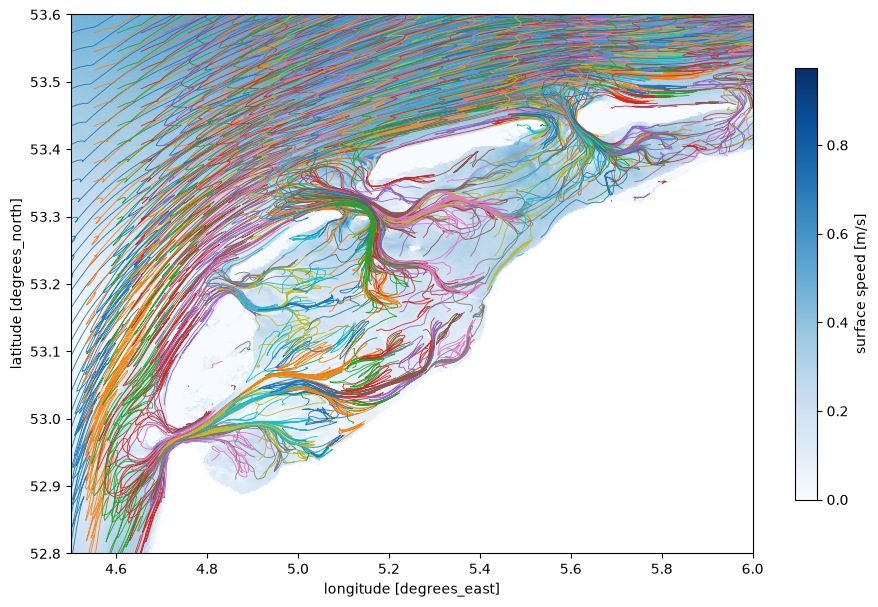

In [8]:
df = parcels.read_particlefile("output-matroos.parquet")

tri_speed = ds["veluv_abs"].isel(time=0).isel(nMesh_face=xr.DataArray(tri_parent_face, dims="n_face")).values

fig, ax = plt.subplots(figsize=(11, 7))
tpc = ax.tripcolor(
    triang,
    facecolors=tri_speed,
    shading="flat",
    cmap="Blues",
    vmax=np.nanpercentile(tri_speed, 98),
)
# ax.triplot(triang, color="k", lw=0.2, alpha=0.35)
ax.set_xlim([4.5, 6])
ax.set_ylim([52.8, 53.6])
ax.set_xlabel("longitude [degrees_east]")
ax.set_ylabel("latitude [degrees_north]")
fig.colorbar(tpc, ax=ax, label="surface speed [m/s]", shrink=0.8)

for traj in df.partition_by("particle_id"):
    ax.plot(
        np.array(traj["lon"]),
        np.array(traj["lat"]),
        lw=0.6,
        zorder=2,
    )

plt.show()